<a href="https://colab.research.google.com/github/angelfrancomorales/INFO648-Summer2026/blob/main/Lesson_01_Intro/INFO648_Day1_Classwork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
print("Hello␣World!")
# This is my first day...fun fun fun


Hello␣World!


Here we are just playing with text:

Above I printed words.

#section 5 all about me

$$\int 5x+2$$

Working with wage data

In [7]:
import pandas as pd


This is an example of reaching out and pulling data down from a website.
Pandas pulls the file in with the function pd.read_csv and calls it wage_df.

In [9]:
url="https://raw.githubusercontent.com/JWarmenhoven/ISLR-python/master/Notebooks/Data/Wage.csv"
wage_df = pd.read_csv(url)

In [10]:
url="https://raw.githubusercontent.com/JWarmenhoven/ISLR-python/master/Notebooks/Data/Wage.csv"
wage_df = pd.read_csv(url)

In [11]:
wage_df.info()
wage_df.describe()
# describe my numeric data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  3000 non-null   int64  
 1   year        3000 non-null   int64  
 2   age         3000 non-null   int64  
 3   sex         3000 non-null   object 
 4   maritl      3000 non-null   object 
 5   race        3000 non-null   object 
 6   education   3000 non-null   object 
 7   region      3000 non-null   object 
 8   jobclass    3000 non-null   object 
 9   health      3000 non-null   object 
 10  health_ins  3000 non-null   object 
 11  logwage     3000 non-null   float64
 12  wage        3000 non-null   float64
dtypes: float64(2), int64(3), object(8)
memory usage: 304.8+ KB


,Unnamed: 0,year,age,logwage,wage
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,218883.373000,2005.791000,42.414667,4.653905,111.703608
std,145654.072587,2.026167,11.542406,0.351753,41.728595
min,7373.000000,2003.000000,18.000000,3.000000,20.085537
25%,85622.250000,2004.000000,33.750000,4.447158,85.383940
50%,228799.500000,2006.000000,42.000000,4.653213,104.921507
75%,374759.500000,2008.000000,51.000000,4.857332,128.680488
max,453870.000000,2009.000000,80.000000,5.763128,318.342430


Descriptive Analysis


Cross tab comes in very handy to get a count of categorical variables.
You should also try to run this code:
wage_df["education"].value_counts()

In [13]:
pd.crosstab(wage_df['sex'], wage_df['education'])

education,1. < HS Grad,2. HS Grad,3. Some College,4. College Grad,5. Advanced Degree
sex,,,,,
1. Male,268,971,650,685,426


Hopefully by now you see our data frame has a name, and that name is wage_df.
If I want to refer to a column, I use brackets and quotes.
So to isolate the education column, I use:
wage_df[’education’]

Plotting in Python

<Axes: xlabel='age', ylabel='wage'>

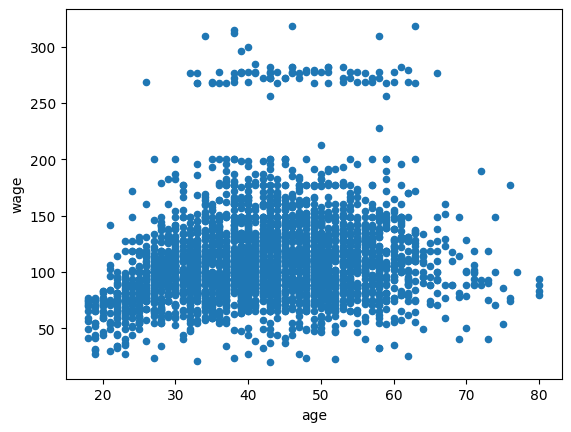

In [15]:
wage_df.plot(x='age', y='wage', kind="scatter")

<Axes: title={'center': 'wage'}, xlabel='education'>

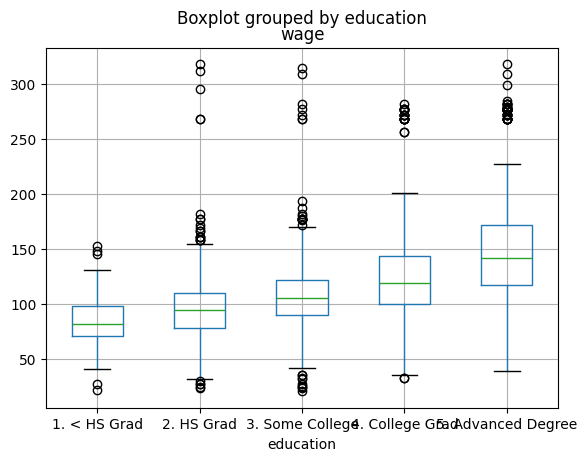

In [16]:
wage_df.boxplot(column="wage", by="education")

In [17]:
import pandas as pd
import requests

In [31]:
series_ids = {
"Bachelors_Only" : "LEU0252919100",
"Bachelors_Plus" : "LEU0252918500",
"HS_Grad" : "LEU0252917300",
"Less_than_HS" : "LEU0252916700",
"Men_Bachelors_Plus" : "LEU0252922500",
"Women_Bachelors_Plus" : "LEU0252926500",
"HS_Grad_Cert" : "LEU0259295900"
}
start_year = 2015
end_year = 2024

In [32]:
url = "https://api.bls.gov/publicAPI/v2/timeseries/data/"
payload = {
"seriesid" : list ( series_ids . values () ) ,
"startyear" : start_year ,
"endyear" : end_year
}
response = requests . post ( url , json = payload )
data = response . json ()

In [24]:
import json
print(json.dumps(data, indent=2))

{
  "status": "REQUEST_FAILED_INVALID_PARAMETERS",
  "responseTime": 0,
  "message": [
    "endyear: Value must be a four-digit number."
  ],
  "Results": {}
}


In [33]:
records = []
for series in data['Results']['series']:
    series_name = [k for k, v in series_ids.items() if v == series['seriesID']][0]
    for item in series['data']:
        records.append({
            "Year": int(item['year']),
            "Period": item['period'],
            "Value": float(item['value']),
            "Series": series_name
        })

In [34]:
wage_bls_df = pd.DataFrame(records)
print(wage_bls_df.head())

   Year Period   Value          Series
0  2024    Q04  1547.0  Bachelors_Only
1  2024    Q03  1533.0  Bachelors_Only
2  2024    Q02  1541.0  Bachelors_Only
3  2024    Q01  1551.0  Bachelors_Only
4  2023    Q04  1509.0  Bachelors_Only


In [28]:
print(data.keys())

dict_keys(['status', 'responseTime', 'message', 'Results'])


In [37]:
df_long = pd.DataFrame(records)
df_long.head()

,Year,Period,Value,Series
0,2024,Q04,1547.0,Bachelors_Only
1,2024,Q03,1533.0,Bachelors_Only
2,2024,Q02,1541.0,Bachelors_Only
3,2024,Q01,1551.0,Bachelors_Only
4,2023,Q04,1509.0,Bachelors_Only


In [39]:
df_annual = (
df_long
.groupby(['Year', 'Series'])['Value']
.mean()
.reset_index()
)

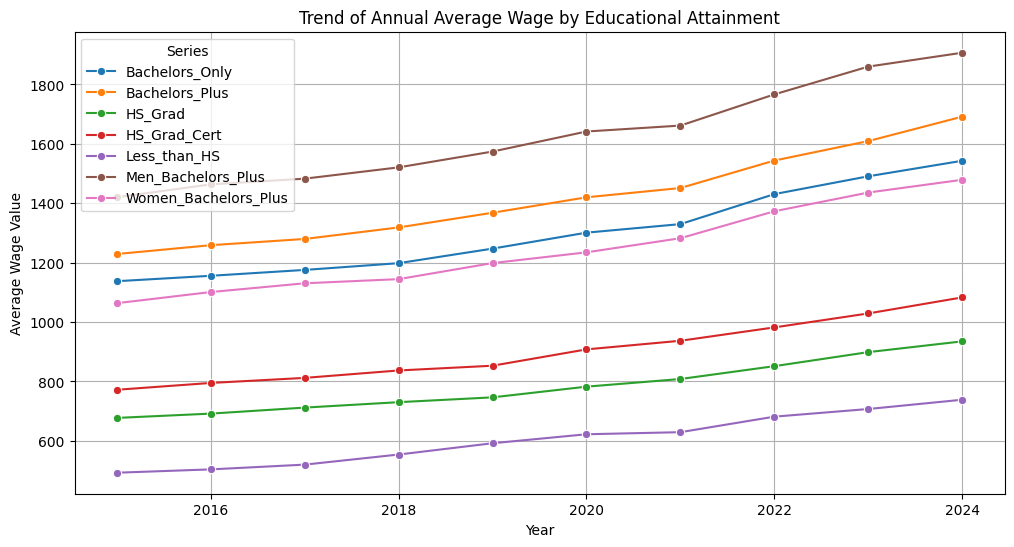

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_annual, x='Year', y='Value', hue='Series', marker='o')
plt.title('Trend of Annual Average Wage by Educational Attainment')
plt.xlabel('Year')
plt.ylabel('Average Wage Value')
plt.grid(True)
plt.legend(title='Series')
plt.show()

In [42]:
df_wide = df_annual . pivot (
index = 'Year' ,
columns = 'Series' ,
values = 'Value'
) . reset_index ()

In [43]:
first_year = df_wide['Year'].min()
last_year = df_wide['Year'].max()

wages_first_year = df_wide[df_wide['Year'] == first_year].iloc[0]
wages_last_year = df_wide[df_wide['Year'] == last_year].iloc[0]

# Calculate percentage growth for each series, excluding the 'Year' column
percentage_growth = {}
for col in df_wide.columns:
    if col != 'Year':
        if wages_first_year[col] != 0:
            growth = ((wages_last_year[col] - wages_first_year[col]) / wages_first_year[col]) * 100
            percentage_growth[col] = growth
        else:
            percentage_growth[col] = float('inf') if wages_last_year[col] != 0 else 0.0 # Handle division by zero

# Convert to a DataFrame for better display
growth_df = pd.DataFrame(percentage_growth.items(), columns=['Series', 'Percentage Growth (%)'])
display(growth_df.sort_values(by='Percentage Growth (%)', ascending=False))

,Series,Percentage Growth (%)
4,Less_than_HS,49.873161
3,HS_Grad_Cert,40.284974
6,Women_Bachelors_Plus,39.069111
2,HS_Grad,38.058324
1,Bachelors_Plus,37.632221
0,Bachelors_Only,35.648352
5,Men_Bachelors_Plus,34.254533


/tmp/ipykernel_499/2350025545.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Percentage Growth (%)', y='Series', data=growth_df.sort_values(by='Percentage Growth (%)', ascending=False), palette='viridis')


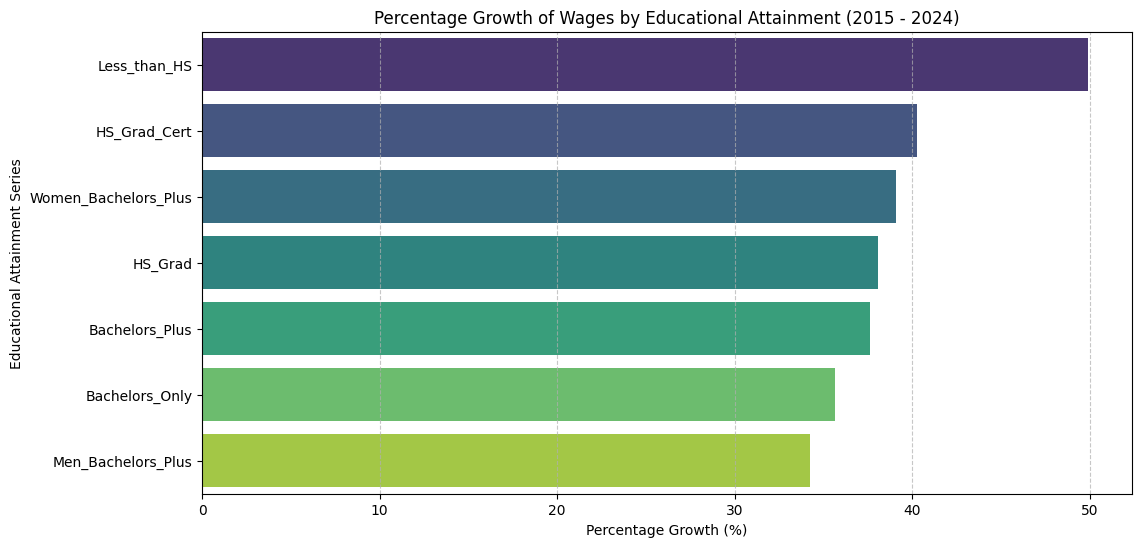

In [44]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Percentage Growth (%)', y='Series', data=growth_df.sort_values(by='Percentage Growth (%)', ascending=False), palette='viridis')
plt.title('Percentage Growth of Wages by Educational Attainment ({} - {})'.format(first_year, last_year))
plt.xlabel('Percentage Growth (%)')
plt.ylabel('Educational Attainment Series')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

<Axes: xlabel='Year'>

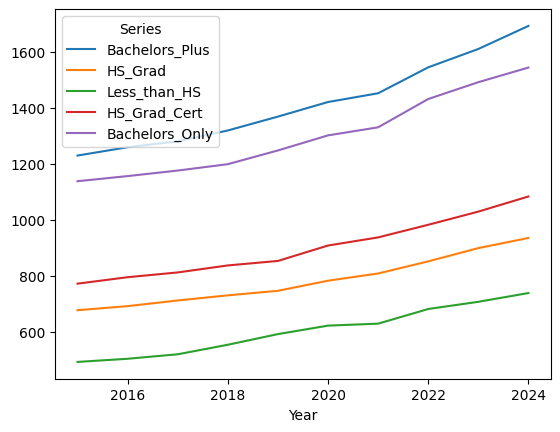

In [46]:
df_wide . plot (
x = 'Year' ,
y =['Bachelors_Plus', 'HS_Grad',
'Less_than_HS', 'HS_Grad_Cert',
'Bachelors_Only']
)

In [47]:
df_wide.describe()

Series,Year,Bachelors_Only,Bachelors_Plus,HS_Grad,HS_Grad_Cert,Less_than_HS,Men_Bachelors_Plus,Women_Bachelors_Plus
count,10.00000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,2019.50000,1300.950000,1416.975000,783.375000,900.800000,604.150000,1629.750000,1244.300000
std,3.02765,145.012394,156.661633,88.503708,105.204351,86.797353,169.219819,144.591273
min,2015.00000,1137.500000,1229.000000,677.250000,772.000000,492.750000,1420.250000,1063.500000
25%,2017.25000,1181.187500,1289.437500,716.562500,818.250000,528.500000,1492.250000,1134.000000
50%,2019.50000,1274.125000,1394.000000,764.500000,880.500000,607.125000,1607.750000,1216.625000
75%,2021.75000,1405.500000,1520.625000,840.687500,970.750000,668.437500,1740.250000,1350.312500
max,2024.00000,1543.000000,1691.500000,935.000000,1083.000000,738.500000,1906.750000,1479.000000


In [48]:
correlation_matrix = df_wide.drop(columns=['Year']).corr()
display(correlation_matrix)

Series,Bachelors_Only,Bachelors_Plus,HS_Grad,HS_Grad_Cert,Less_than_HS,Men_Bachelors_Plus,Women_Bachelors_Plus
Series,,,,,,,
Bachelors_Only,1.000000,0.997952,0.997325,0.995534,0.988356,0.998077,0.998028
Bachelors_Plus,0.997952,1.000000,0.998293,0.997654,0.991130,0.997924,0.996848
HS_Grad,0.997325,0.998293,1.000000,0.998774,0.987330,0.997596,0.997244
HS_Grad_Cert,0.995534,0.997654,0.998774,1.000000,0.988193,0.995925,0.994881
Less_than_HS,0.988356,0.991130,0.987330,0.988193,1.000000,0.991319,0.988578
Men_Bachelors_Plus,0.998077,0.997924,0.997596,0.995925,0.991319,1.000000,0.997708
Women_Bachelors_Plus,0.998028,0.996848,0.997244,0.994881,0.988578,0.997708,1.000000


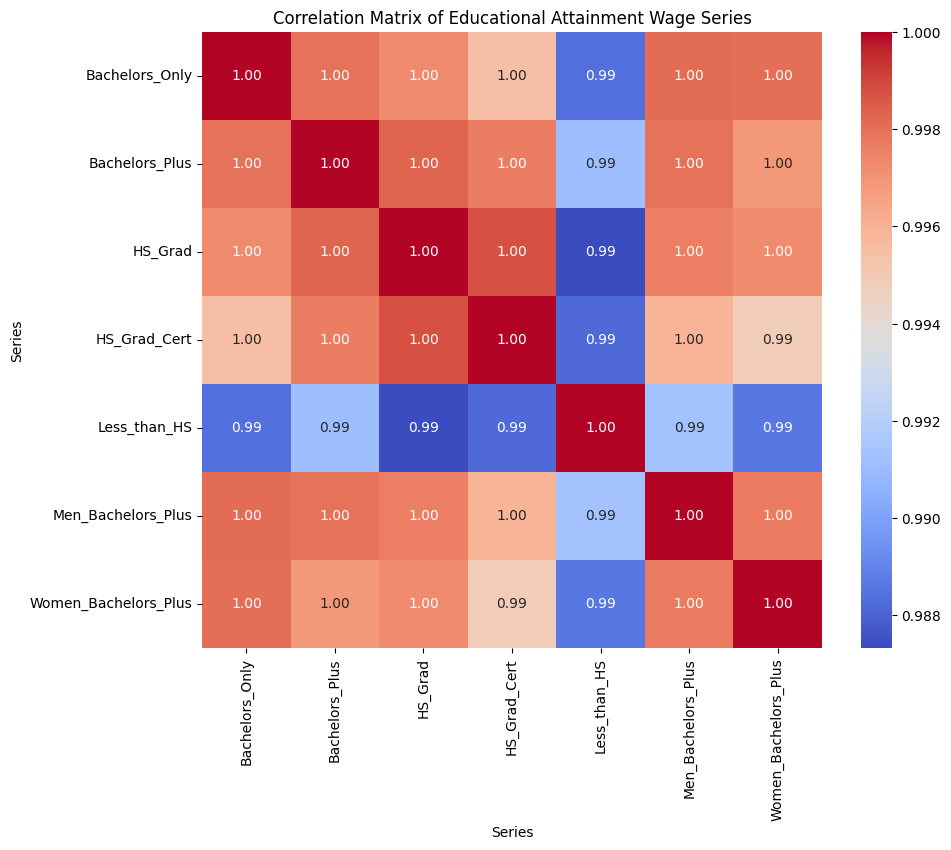

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Educational Attainment Wage Series')
plt.show()